<a href="https://colab.research.google.com/github/sandrahany00/Teeth_classification/blob/main/Teeth_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# from google.colab import files
# files.upload()

In [ ]:
import zipfile
import os

zip_file_path = '/content/Teeth DataSet.zip'
output_dir = '/content/Teeth DataSet'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"File unzipped to {output_dir}")

File unzipped to /content/Teeth DataSet


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [ ]:
IMAGE_SIZE=(224,224)
# cnn size
BATCH_SIZE=32

In [ ]:
train_dataset=tf.keras.utils.image_dataset_from_directory(
    "/content/Teeth DataSet/Teeth_Dataset/Training",
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
)

Found 3087 files belonging to 7 classes.


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/Teeth DataSet/Teeth_Dataset/Training",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)
class_names = train_dataset.class_names
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/Teeth DataSet/Teeth_Dataset/Testing",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)
validate_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/Teeth DataSet/Teeth_Dataset/Validation",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)



Found 3087 files belonging to 7 classes.
Found 1508 files belonging to 10 classes.
Found 1028 files belonging to 7 classes.


In [ ]:
print(train_dataset.class_names)
print(test_dataset.class_names)
print(validate_dataset.class_names)


['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT', 'out', 'output', 'outputs']
['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

val_dataset = validate_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)


In [ ]:
for images, labels in train_dataset.take(1):
    print(images.numpy().min(), images.numpy().max())


0.0 1.0


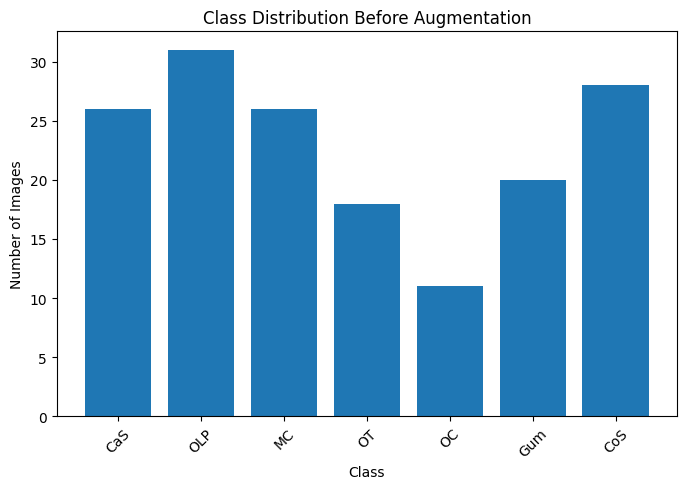

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
class_counts = {}

for images, labels in train_dataset.take(5):
    for label in labels.numpy():
        class_name = class_names[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution Before Augmentation")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


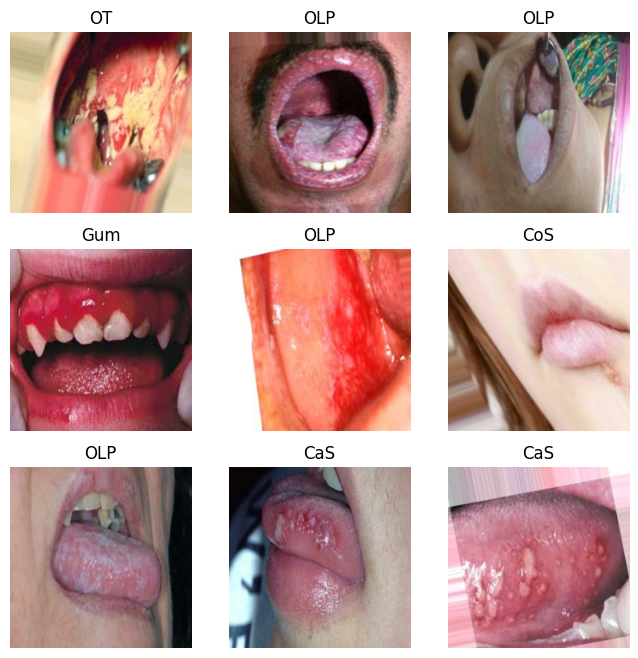

In [ ]:
plt.figure(figsize=(8, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()


In [ ]:
print(class_counts)


{'CaS': 26, 'OLP': 31, 'MC': 26, 'OT': 18, 'OC': 11, 'Gum': 20, 'CoS': 28}


In [149]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomFlip("horizontal"),
])


In [ ]:
plt.figure(figsize=(8, 8))
# for visualization only

for images, labels in train_dataset.take(1):
    # images=images/255.0
    augmented_images = data_augmentation(images)
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(augmented_images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()


In [ ]:
print(augmented_images[0].numpy().min(), augmented_images[0].numpy().max())


In [ ]:
print(class_counts)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_dataset.prefetch(AUTOTUNE)
val_ds   = validate_dataset.prefetch(AUTOTUNE)
test_ds  = test_dataset.prefetch(AUTOTUNE)


In [155]:
from tensorflow.keras import layers, models
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)      # training only
x = normalization_layer(x)

x = layers.Conv2D(32, 3, activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

num_classes = len(class_names)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_16 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_13 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [156]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [157]:
from sklearn.utils.class_weight import compute_class_weight
labels = []
for _, y in train_ds:
    labels.extend(y.numpy())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
class_weights


{0: np.float64(0.91875),
 1: np.float64(0.98),
 2: np.float64(1.225),
 3: np.float64(0.8166666666666667),
 4: np.float64(1.3611111111111112),
 5: np.float64(0.8166666666666667),
 6: np.float64(1.1221374045801527)}

In [158]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)


Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.1519 - loss: 1.9566 - val_accuracy: 0.1576 - val_loss: 2.0370
Epoch 2/10
50/97 ━━━━━━━━━━━━━━━━━━━━ 1:45 2s/step - accuracy: 0.1284 - loss: 1.9553

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)
